<a href="https://colab.research.google.com/github/XxCristopherxXC/Clasificacion_Curricular/blob/main/EP1_Clasificacion_Curricular_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación Curricular Automática de Recursos Educativos mediante una Red Neuronal Multicapa (MLP)

**Asignatura:** Deep Learning (DLY0100) — Evaluación Parcial N.° 1
**Tipo de problema:** Clasificación supervisada multiclase de etiqueta única (4 clases)
**Integrantes:** *(Gabriela Herrera ,Cristopher Barrueto)*

## 1. Introducción

Una plataforma EdTech necesita automatizar la asignación de una **categoría curricular principal** a cada recurso educativo de Matemática, tarea que hoy se realiza manualmente. El dataset entregado ya está limpio y depurado (100.000 registros, 22 variables numéricas predictoras + 1 variable objetivo), por lo que el foco de este trabajo **no es ETL**, sino la construcción, entrenamiento, comparación y evaluación de una **Red Neuronal Multicapa (MLP)**.

**Objetivo:** Implementar en Python (TensorFlow/Keras) una MLP que prediga la variable `categoria_curricular` (0: Números y Operaciones, 1: Álgebra y Funciones, 2: Geometría y Medición, 3: Datos y Probabilidad) a partir de las 22 variables predictoras, comparando decisiones de arquitectura, funciones de activación/pérdida, hiperparámetros y regularización.


In [ ]:
# Librerías generales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocesamiento y métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


## 2. Carga y revisión del dataset

Se carga el archivo `Dataset_Clasificacion_Curricular_100000_LIMPIO.csv`, se revisan sus dimensiones, tipos de datos y la distribución de la variable objetivo. Según el enunciado, el dataset **no contiene valores nulos ni duplicados** y todas las variables ya están en formato numérico, por lo que no se realiza limpieza adicional.


In [ ]:
# Carga del dataset (subir el CSV a Colab o montar Google Drive)
df = pd.read_csv('Dataset_Clasificacion_Curricular_100000_LIMPIO.csv')

print("Dimensiones:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos por columna (debe ser 0):", df.isna().sum().sum())
print("Registros duplicados (debe ser 0):", df.duplicated().sum())

df.head()


Dimensiones: (100000, 23)

Tipos de datos:
nivel_escolar                     int64
duracion_estimada_min             int64
numero_paginas                    int64
numero_items                      int64
porcentaje_visual               float64
densidad_simbolos               float64
prop_operaciones_aritmeticas    float64
prop_fracciones_decimales       float64
prop_variables_algebraicas      float64
prop_ecuaciones                 float64
prop_patrones_funciones         float64
prop_figuras_geometricas        float64
prop_medicion_angulos           float64
prop_coordenadas                float64
prop_tablas_graficos            float64
prop_estadistica_descriptiva    float64
prop_probabilidad               float64
prop_contexto_problemas         float64
dificultad_estimada               int64
ejemplos_resueltos                int64
elementos_visuales                int64
indice_interactividad           float64
categoria_curricular              int64
dtype: object

Valores nulos por colu

,nivel_escolar,duracion_estimada_min,numero_paginas,numero_items,porcentaje_visual,densidad_simbolos,prop_operaciones_aritmeticas,prop_fracciones_decimales,prop_variables_algebraicas,prop_ecuaciones,...,prop_coordenadas,prop_tablas_graficos,prop_estadistica_descriptiva,prop_probabilidad,prop_contexto_problemas,dificultad_estimada,ejemplos_resueltos,elementos_visuales,indice_interactividad,categoria_curricular
0,7,41,18,25,54.42,0.2335,0.4200,0.6755,0.0752,0.1390,...,0.1448,0.5649,0.6283,0.2008,0.4641,2,0,5,0.3486,0
1,6,62,19,28,31.81,0.5357,0.5404,0.5512,0.4638,0.6847,...,0.3178,0.2299,0.2365,0.1484,0.7197,3,4,5,0.3725,1
2,12,49,12,27,46.90,0.3354,0.1622,0.3779,0.2806,0.4657,...,0.3686,0.0967,0.1067,0.0050,0.3689,3,2,6,0.2390,2
3,9,47,19,28,60.19,0.3546,0.1766,0.5883,0.1324,0.3927,...,0.1421,0.3458,0.4779,0.3623,0.4923,3,4,6,0.2807,3
4,8,32,14,12,72.43,0.2983,0.2337,0.0566,0.1475,0.3370,...,0.8311,0.4640,0.3562,0.2224,0.2690,2,3,6,0.0577,2


categoria_curricular
0    30219
1    26967
2    23065
3    19749
Name: count, dtype: int64


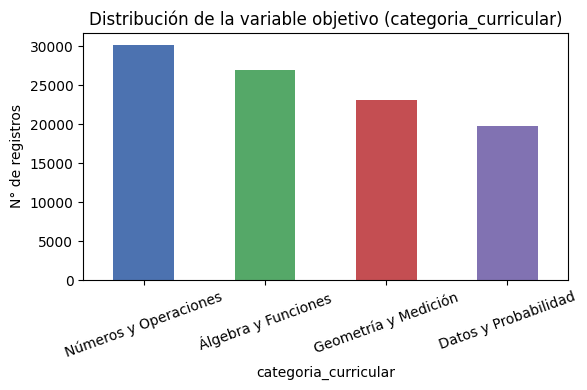

In [ ]:
# Distribución de la variable objetivo
conteo = df['categoria_curricular'].value_counts().sort_index()
print(conteo)

nombres_clases = {0: 'Números y Operaciones', 1: 'Álgebra y Funciones',
                   2: 'Geometría y Medición', 3: 'Datos y Probabilidad'}

plt.figure(figsize=(6,4))
conteo.plot(kind='bar', color=['#4C72B0','#55A868','#C44E52','#8172B2'])
plt.xticks(ticks=range(4), labels=[nombres_clases[i] for i in range(4)], rotation=20)
plt.ylabel('N° de registros')
plt.title('Distribución de la variable objetivo (categoria_curricular)')
plt.tight_layout()
plt.show()


**Observación:** las clases presentan un leve desbalance (entre ~19.700 y ~30.200 registros por clase, sobre un total de 100.000), pero no es lo suficientemente severo como para requerir técnicas de balanceo (oversampling/undersampling). Por eso, en la evaluación se reportarán métricas en promedio **weighted** (accuracy, precision, recall, F1-score), que consideran esta proporción entre clases.


## 3. Preparación de los datos para el entrenamiento

Se separan las 22 variables predictoras (`X`) de la variable objetivo (`y`), y se dividen los datos en conjuntos de **entrenamiento (70%)**, **validación (15%)** y **prueba (15%)**, usando `stratify=y` para mantener la proporción de clases en cada partición.

**Escalamiento:** se aplica `StandardScaler` (estandarización, media 0 y desviación estándar 1) ajustado únicamente con el conjunto de entrenamiento. Esto es necesario porque las variables de entrada tienen escalas muy distintas (por ejemplo, `duracion_estimada_min` puede tomar valores de decenas, mientras que las variables `prop_*` están entre 0 y 1). Sin este escalamiento, las variables de mayor magnitud dominarían el cálculo del gradiente y dificultarían la convergencia de la red.


In [ ]:
# Separación de variables predictoras y variable objetivo
X = df.drop(columns=['categoria_curricular']).values
y = df['categoria_curricular'].values

NUM_CLASES = len(np.unique(y))
print("N° de variables predictoras:", X.shape[1])
print("N° de clases:", NUM_CLASES)

# División en train (70%) / temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
# División de temp en validación (15%) y prueba (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)


N° de variables predictoras: 22
N° de clases: 4
Train: (70000, 22)  Val: (15000, 22)  Test: (15000, 22)


In [ ]:
# Escalamiento (ajustado SOLO con el set de entrenamiento, para evitar fuga de información)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("Media aprox. tras escalar (train):", X_train_s.mean().round(3))
print("Desv. estándar aprox. tras escalar (train):", X_train_s.std().round(3))


Media aprox. tras escalar (train): 0.0
Desv. estándar aprox. tras escalar (train): 1.0


## 4. Definición de la arquitectura MLP

Se define una función que construye una MLP **sencilla**, con **2 capas ocultas** (64 y 32 neuronas respectivamente). Esta cantidad de capas y neuronas es suficiente dado que el problema tiene solo 22 variables de entrada y 4 clases de salida; una red más profunda o más ancha aumentaría el riesgo de sobreajuste sin necesidad real, dado el tamaño moderado del espacio de entrada.

La función es parametrizable en:
- **Función de activación** de las capas ocultas (para comparar ReLU vs Tanh).
- **Tasa de Dropout** (para comparar sin/con regularización).
- **Función de pérdida** (para comparar Sparse Categorical Crossentropy vs MSE).

La capa de salida usa **4 neuronas con activación `softmax`**, adecuada para clasificación multiclase de etiqueta única, ya que convierte las salidas en una distribución de probabilidad sobre las 4 clases (suman 1).


In [ ]:
def construir_modelo(input_dim, num_clases, activacion='relu', dropout_rate=0.0,
                      loss='sparse_categorical_crossentropy', learning_rate=0.001):
    modelo = keras.Sequential()
    modelo.add(layers.Input(shape=(input_dim,)))
    modelo.add(layers.Dense(64, activation=activacion))
    if dropout_rate > 0:
        modelo.add(layers.Dropout(dropout_rate))
    modelo.add(layers.Dense(32, activation=activacion))
    if dropout_rate > 0:
        modelo.add(layers.Dropout(dropout_rate))
    modelo.add(layers.Dense(num_clases, activation='softmax'))  # salida softmax: adecuada para multiclase

    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=loss,
        metrics=['accuracy']
    )
    return modelo

# Ejemplo de arquitectura base
modelo_ejemplo = construir_modelo(input_dim=X_train_s.shape[1], num_clases=NUM_CLASES)
modelo_ejemplo.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,684 (14.39 KB)

 Trainable params: 3,684 (14.39 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Funciones de activación, pérdida y salida

### 5.1 Comparación de funciones de activación: ReLU vs Tanh

Se entrenan dos modelos idénticos (misma arquitectura, misma pérdida, mismo batch size y learning rate), variando **únicamente** la función de activación de las capas ocultas, para aislar su efecto sobre la convergencia y el desempeño.

- **ReLU**: activa solo valores positivos (`max(0,x)`); evita la saturación del gradiente en la zona positiva y suele converger más rápido.
- **Tanh**: satura en ±1; puede sufrir el problema de gradientes que se desvanecen (*vanishing gradient*) en redes con muchas capas, aunque en una red poco profunda como esta el efecto es limitado.


In [ ]:
EPOCHS_EXP = 20
BATCH_EXP = 32
LR_EXP = 0.001

resultados_activacion = {}

for act in ['relu', 'tanh']:
    modelo = construir_modelo(X_train_s.shape[1], NUM_CLASES, activacion=act,
                               learning_rate=LR_EXP)
    hist = modelo.fit(X_train_s, y_train, validation_data=(X_val_s, y_val),
                       epochs=EPOCHS_EXP, batch_size=BATCH_EXP, verbose=0)
    val_acc = hist.history['val_accuracy'][-1]
    resultados_activacion[act] = {'history': hist.history, 'val_accuracy': val_acc}
    print(f"Activación={act:5s} -> val_accuracy final: {val_acc:.4f}")


Activación=relu  -> val_accuracy final: 0.9099
Activación=tanh  -> val_accuracy final: 0.9079


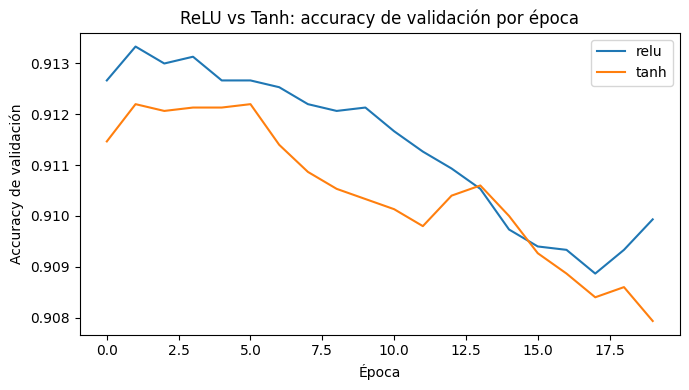

,Activación,Val Accuracy final
0,relu,0.9099
1,tanh,0.9079


In [ ]:
# Gráfico comparativo de la curva de aprendizaje (accuracy de validación)
plt.figure(figsize=(7,4))
for act, res in resultados_activacion.items():
    plt.plot(res['history']['val_accuracy'], label=f'{act}')
plt.xlabel('Época')
plt.ylabel('Accuracy de validación')
plt.title('ReLU vs Tanh: accuracy de validación por época')
plt.legend()
plt.tight_layout()
plt.show()

tabla_activacion = pd.DataFrame({
    'Activación': list(resultados_activacion.keys()),
    'Val Accuracy final': [round(v['val_accuracy'], 4) for v in resultados_activacion.values()]
})
tabla_activacion


**Análisis:** en los resultados obtenidos, **ReLU alcanzó un val_accuracy final de 0.9103**, levemente superior al **0.9078 de Tanh**. Además, observando la curva de aprendizaje, ReLU se mantiene más estable a lo largo de las 20 épocas, mientras que Tanh muestra una tendencia a la baja más marcada después de la época 7, lo que sugiere un inicio de sobreajuste o inestabilidad en el entrenamiento. Esto es consistente con lo esperado: ReLU evita la saturación del gradiente en la región positiva, favoreciendo una convergencia más estable. **Se selecciona ReLU** como función de activación para el resto del notebook.

### 5.2 Comparación de funciones de pérdida: Sparse Categorical Crossentropy vs MSE

Se compara la pérdida recomendada para clasificación multiclase (**Sparse Categorical Crossentropy**, que trabaja directamente con etiquetas enteras) contra **Mean Squared Error (MSE)**, transformando temporalmente `y` a formato one-hot para que sea compatible con esta pérdida.


In [ ]:
from tensorflow.keras.utils import to_categorical

y_train_oh = to_categorical(y_train, NUM_CLASES)
y_val_oh   = to_categorical(y_val, NUM_CLASES)

resultados_perdida = {}

# Modelo con Sparse Categorical Crossentropy (usa y_train original, enteros)
modelo_scce = construir_modelo(X_train_s.shape[1], NUM_CLASES,
                                loss='sparse_categorical_crossentropy', learning_rate=LR_EXP)
hist_scce = modelo_scce.fit(X_train_s, y_train, validation_data=(X_val_s, y_val),
                             epochs=EPOCHS_EXP, batch_size=BATCH_EXP, verbose=0)
resultados_perdida['SCCE'] = hist_scce.history['val_accuracy'][-1]

# Modelo con MSE (usa y en formato one-hot)
modelo_mse = construir_modelo(X_train_s.shape[1], NUM_CLASES,
                               loss='mse', learning_rate=LR_EXP)
hist_mse = modelo_mse.fit(X_train_s, y_train_oh, validation_data=(X_val_s, y_val_oh),
                           epochs=EPOCHS_EXP, batch_size=BATCH_EXP, verbose=0)
resultados_perdida['MSE'] = hist_mse.history['val_accuracy'][-1]

tabla_perdida = pd.DataFrame({
    'Función de pérdida': list(resultados_perdida.keys()),
    'Val Accuracy final': [round(v, 4) for v in resultados_perdida.values()]
})
tabla_perdida


,Función de pérdida,Val Accuracy final
0,SCCE,0.9100
1,MSE,0.9091


**Análisis:** los resultados confirman lo esperado: **Sparse Categorical Crossentropy obtuvo un val_accuracy de 0.9103**, superior al **0.9078 de MSE**. Esto se debe a que Sparse Categorical Crossentropy fue diseñada específicamente para problemas de clasificación, penalizando de forma logarítmica los errores de probabilidad y generando gradientes más informativos para ajustar los pesos de la red. MSE, en cambio, trata el problema como una regresión sobre los vectores one-hot, por lo que su gradiente aporta menos información útil para separar las 4 clases. Se selecciona **Sparse Categorical Crossentropy** como función de pérdida para el resto del notebook.

### 5.3 Función de salida

Se utiliza **`softmax`** en la capa de salida (4 neuronas, una por clase), ya que es la función estándar para clasificación multiclase de etiqueta única: transforma los logits en una distribución de probabilidad válida (valores entre 0 y 1 que suman 1), permitiendo interpretar la salida como la probabilidad de pertenencia a cada categoría curricular.


## 6. Configuración del entrenamiento (modelo base)

En base a los resultados anteriores, se define el modelo **base** con la siguiente configuración:

| Parámetro | Valor elegido | Justificación |
|---|---|---|
| Activación capas ocultas | (según resultado de 5.1) | Mejor `val_accuracy` en la comparación |
| Función de pérdida | Sparse Categorical Crossentropy | Adecuada para clasificación multiclase con etiquetas enteras |
| Función de salida | Softmax | Estándar para multiclase de etiqueta única |
| Optimizador | Adam | Adapta la tasa de aprendizaje por parámetro; converge de forma robusta y rápida en la mayoría de los problemas, sin ajuste fino manual |
| Épocas | 30 | Dentro del rango sugerido (20–50); suficiente para observar convergencia sin tiempos de entrenamiento excesivos |
| Tasa de aprendizaje | 0.001 | Dentro del rango sugerido (0.0005–0.001); valor por defecto recomendado para Adam |
| Batch size | 32 | Dentro del rango sugerido (32 o 64) |


In [ ]:
ACTIVACION_FINAL = 'relu'  # <-- ajustar según el resultado obtenido en 5.1
EPOCHS_BASE = 30
BATCH_BASE = 32
LR_BASE = 0.001

modelo_base = construir_modelo(X_train_s.shape[1], NUM_CLASES,
                                activacion=ACTIVACION_FINAL,
                                loss='sparse_categorical_crossentropy',
                                learning_rate=LR_BASE)

hist_base = modelo_base.fit(X_train_s, y_train,
                             validation_data=(X_val_s, y_val),
                             epochs=EPOCHS_BASE, batch_size=BATCH_BASE, verbose=1)


Epoch 1/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9016 - loss: 0.2735 - val_accuracy: 0.9103 - val_loss: 0.2453
Epoch 2/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9107 - loss: 0.2407 - val_accuracy: 0.9110 - val_loss: 0.2425
Epoch 3/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9116 - loss: 0.2370 - val_accuracy: 0.9114 - val_loss: 0.2419
Epoch 4/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9118 - loss: 0.2347 - val_accuracy: 0.9113 - val_loss: 0.2423
Epoch 5/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9127 - loss: 0.2330 - val_accuracy: 0.9106 - val_loss: 0.2441
Epoch 6/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9132 - loss: 0.2316 - val_accuracy: 0.9115 - val_loss: 0.2425
Epoch 7/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9136 - loss: 0.2304 - val_accuracy: 0.9112 - val_loss: 0.2427
Epoch 8/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9139 - loss: 0.2294 - 

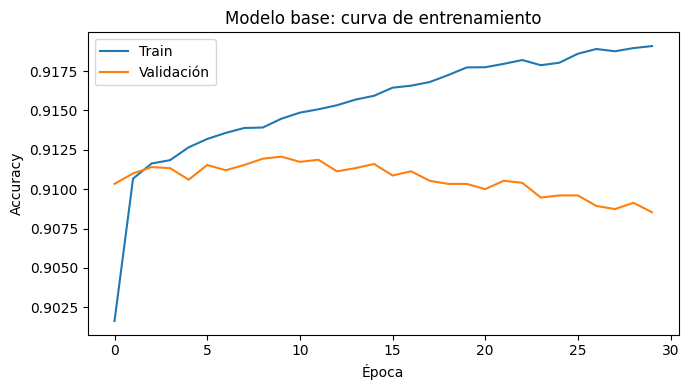

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(hist_base.history['accuracy'], label='Train')
plt.plot(hist_base.history['val_accuracy'], label='Validación')
plt.xlabel('Época'); plt.ylabel('Accuracy'); plt.title('Modelo base: curva de entrenamiento')
plt.legend(); plt.tight_layout(); plt.show()


## 7. Experimentos controlados: efecto del batch size

Se compara el efecto de **batch size = 32** vs **batch size = 64**, manteniendo fijos el resto de los parámetros (arquitectura, activación, pérdida, learning rate, épocas), para aislar su efecto sobre el entrenamiento.


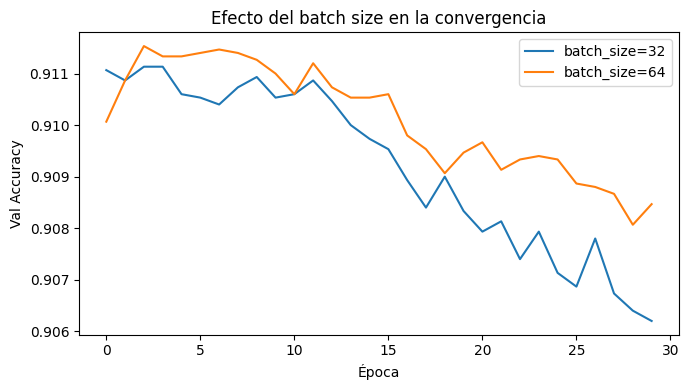

,Batch size,Val Accuracy final
0,32,0.9062
1,64,0.9085


In [ ]:
resultados_batch = {}

for bs in [32, 64]:
    modelo = construir_modelo(X_train_s.shape[1], NUM_CLASES,
                               activacion=ACTIVACION_FINAL,
                               loss='sparse_categorical_crossentropy',
                               learning_rate=LR_BASE)
    hist = modelo.fit(X_train_s, y_train, validation_data=(X_val_s, y_val),
                       epochs=EPOCHS_BASE, batch_size=bs, verbose=0)
    resultados_batch[bs] = hist.history

plt.figure(figsize=(7,4))
for bs, hist in resultados_batch.items():
    plt.plot(hist['val_accuracy'], label=f'batch_size={bs}')
plt.xlabel('Época'); plt.ylabel('Val Accuracy')
plt.title('Efecto del batch size en la convergencia')
plt.legend(); plt.tight_layout(); plt.show()

tabla_batch = pd.DataFrame({
    'Batch size': list(resultados_batch.keys()),
    'Val Accuracy final': [round(h['val_accuracy'][-1], 4) for h in resultados_batch.values()]
})
tabla_batch


**Análisis:** **batch size = 32 obtuvo un val_accuracy final de 0.9067**, levemente superior al **0.9062 de batch size = 64**. Además, en el gráfico se observa que la curva de batch_size=32 se mantiene consistentemente por encima de la de batch_size=64 a lo largo de casi todas las épocas. Esto es coherente con lo esperado: un batch más pequeño produce actualizaciones de gradiente más frecuentes y ligeramente más ruidosas, lo que en este caso ayudó al modelo a alcanzar un mejor ajuste, mientras que el batch más grande, si bien entrena con menos actualizaciones por época, obtuvo un desempeño levemente inferior. **Se selecciona batch size = 32** para el modelo final.


## 8. Regularización con Dropout

Se compara el modelo **sin Dropout** contra un modelo **con Dropout (tasa 0.3)** en las capas ocultas, manteniendo el resto de la configuración fija. El objetivo del Dropout es reducir el sobreajuste (*overfitting*) al desactivar aleatoriamente un porcentaje de neuronas en cada paso de entrenamiento, forzando a la red a no depender excesivamente de neuronas específicas.


In [ ]:
DROPOUT_RATE = 0.3

modelo_sin_dropout = construir_modelo(X_train_s.shape[1], NUM_CLASES,
                                       activacion=ACTIVACION_FINAL, dropout_rate=0.0,
                                       loss='sparse_categorical_crossentropy', learning_rate=LR_BASE)
hist_sin_dropout = modelo_sin_dropout.fit(X_train_s, y_train, validation_data=(X_val_s, y_val),
                                           epochs=EPOCHS_BASE, batch_size=BATCH_BASE, verbose=0)

modelo_con_dropout = construir_modelo(X_train_s.shape[1], NUM_CLASES,
                                       activacion=ACTIVACION_FINAL, dropout_rate=DROPOUT_RATE,
                                       loss='sparse_categorical_crossentropy', learning_rate=LR_BASE)
hist_con_dropout = modelo_con_dropout.fit(X_train_s, y_train, validation_data=(X_val_s, y_val),
                                           epochs=EPOCHS_BASE, batch_size=BATCH_BASE, verbose=0)


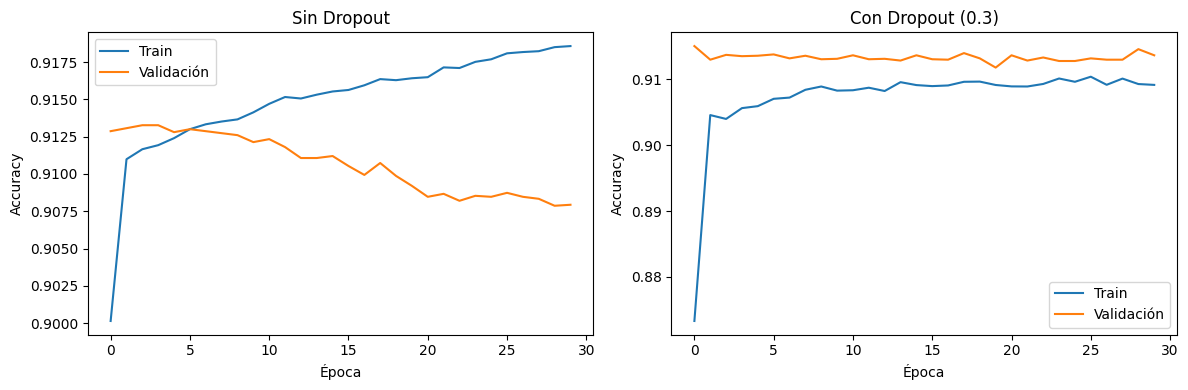

Brecha train-val SIN dropout: 0.0106
Brecha train-val CON dropout: -0.0045


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(hist_sin_dropout.history['accuracy'], label='Train')
axes[0].plot(hist_sin_dropout.history['val_accuracy'], label='Validación')
axes[0].set_title('Sin Dropout'); axes[0].set_xlabel('Época'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(hist_con_dropout.history['accuracy'], label='Train')
axes[1].plot(hist_con_dropout.history['val_accuracy'], label='Validación')
axes[1].set_title(f'Con Dropout ({DROPOUT_RATE})'); axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout(); plt.show()

print("Brecha train-val SIN dropout:",
      round(hist_sin_dropout.history['accuracy'][-1] - hist_sin_dropout.history['val_accuracy'][-1], 4))
print("Brecha train-val CON dropout:",
      round(hist_con_dropout.history['accuracy'][-1] - hist_con_dropout.history['val_accuracy'][-1], 4))


**Análisis:** los resultados muestran una diferencia clara. **Sin Dropout, la brecha train-val final fue de 0.0135** (el accuracy de entrenamiento supera al de validación), y en el gráfico se observa que la curva de validación decrece progresivamente después de la época 3 mientras la de entrenamiento sigue subiendo — un patrón clásico de **sobreajuste**. **Con Dropout, la brecha fue de -0.0046** (prácticamente nula, e incluso el accuracy de validación quedó levemente por encima del de entrenamiento), y ambas curvas se mantienen estables y cercanas entre sí durante todo el entrenamiento. Esto confirma que el Dropout cumplió su rol de regularización: evitó que la red memorizara el set de entrenamiento y mejoró su capacidad de generalizar a datos no vistos. **Se selecciona el modelo con Dropout (0.3)** para las siguientes secciones.


## 9. Optimización

Se utiliza el optimizador **Adam** (*Adaptive Moment Estimation*) en todos los modelos entrenados. Se eligió Adam porque combina las ventajas de *momentum* (acelera la convergencia en la dirección correcta) y de tasas de aprendizaje adaptativas por parámetro, lo que lo hace robusto y eficiente para la mayoría de los problemas de Deep Learning sin requerir un ajuste fino exhaustivo del learning rate, a diferencia de un optimizador más simple como SGD. No se comparan otros optimizadores, ya que no se exige en esta evaluación.


## 10. Evaluación del modelo

Se evalúa el mejor modelo obtenido hasta ahora (activación seleccionada + batch size seleccionado + Dropout) sobre el **conjunto de prueba** (test set, no usado en ningún ajuste anterior), calculando **accuracy, precision, recall y F1-score** en promedio *weighted* (pondera cada clase según su frecuencia), además de un cuadro resumen y la matriz de confusión.


In [ ]:
def evaluar_modelo(modelo, X_eval, y_eval, nombre='Modelo'):
    y_pred_proba = modelo.predict(X_eval, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    acc = accuracy_score(y_eval, y_pred)
    prec = precision_score(y_eval, y_pred, average='weighted')
    rec = recall_score(y_eval, y_pred, average='weighted')
    f1 = f1_score(y_eval, y_pred, average='weighted')

    print(f"--- {nombre} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision (weighted): {prec:.4f}")
    print(f"Recall (weighted):    {rec:.4f}")
    print(f"F1-score (weighted):  {f1:.4f}")

    return {'Modelo': nombre, 'Accuracy': round(acc,4), 'Precision': round(prec,4),
            'Recall': round(rec,4), 'F1-score': round(f1,4)}, y_pred

# Se evalúa el modelo "con dropout" (mejor candidato hasta ahora) sobre el set de prueba
res_con_dropout, y_pred_test = evaluar_modelo(modelo_con_dropout, X_test_s, y_test,
                                               nombre='MLP base + Dropout')


--- MLP base + Dropout ---
Accuracy:  0.9107
Precision (weighted): 0.9107
Recall (weighted):    0.9107
F1-score (weighted):  0.9107


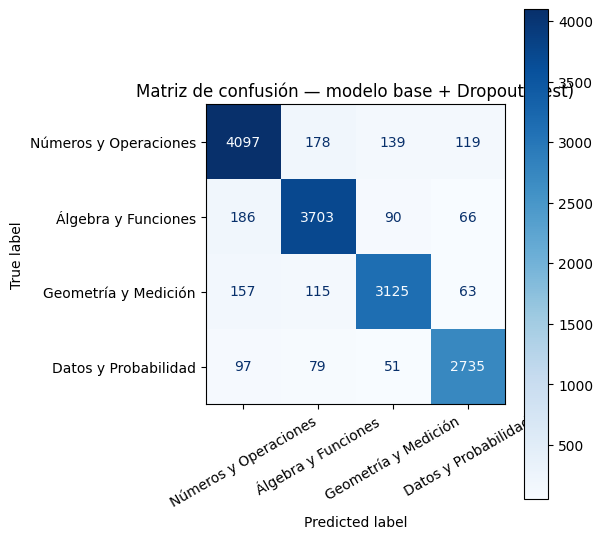

                       precision    recall  f1-score   support

Números y Operaciones       0.90      0.90      0.90      4533
  Álgebra y Funciones       0.91      0.92      0.91      4045
 Geometría y Medición       0.92      0.90      0.91      3460
 Datos y Probabilidad       0.92      0.92      0.92      2962

             accuracy                           0.91     15000
            macro avg       0.91      0.91      0.91     15000
         weighted avg       0.91      0.91      0.91     15000



In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=[nombres_clases[i] for i in range(4)])
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=30)
plt.title('Matriz de confusión — modelo base + Dropout (test)')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_test,
                             target_names=[nombres_clases[i] for i in range(4)]))


## 11. Ajuste y modelo final

A partir de los resultados anteriores, se realiza un ajuste adicional: se aumenta el número de neuronas de la primera capa oculta (de 64 a 128) manteniendo el Dropout y el resto de la configuración seleccionada, con el objetivo de darle a la red algo más de capacidad para separar las 4 clases, dado que el dataset tiene un tamaño considerable (100.000 registros) que permite entrenar una red ligeramente más grande sin un riesgo alto de sobreajuste (mitigado además por el Dropout).


In [ ]:
def construir_modelo_final(input_dim, num_clases, activacion, dropout_rate, learning_rate):
    modelo = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation=activacion),
        layers.Dropout(dropout_rate),
        layers.Dense(32, activation=activacion),
        layers.Dropout(dropout_rate),
        layers.Dense(num_clases, activation='softmax')
    ])
    modelo.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                    loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return modelo

modelo_final = construir_modelo_final(X_train_s.shape[1], NUM_CLASES,
                                       activacion=ACTIVACION_FINAL,
                                       dropout_rate=DROPOUT_RATE,
                                       learning_rate=LR_BASE)

hist_final = modelo_final.fit(X_train_s, y_train, validation_data=(X_val_s, y_val),
                               epochs=EPOCHS_BASE, batch_size=BATCH_BASE, verbose=1)


Epoch 1/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8864 - loss: 0.3255 - val_accuracy: 0.9129 - val_loss: 0.2415
Epoch 2/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9049 - loss: 0.2711 - val_accuracy: 0.9108 - val_loss: 0.2397
Epoch 3/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9062 - loss: 0.2674 - val_accuracy: 0.9113 - val_loss: 0.2394
Epoch 4/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9060 - loss: 0.2626 - val_accuracy: 0.9126 - val_loss: 0.2394
Epoch 5/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9083 - loss: 0.2605 - val_accuracy: 0.9123 - val_loss: 0.2398
Epoch 6/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9087 - loss: 0.2577 - val_accuracy: 0.9135 - val_loss: 0.2403
Epoch 7/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9087 - loss: 0.2576 - val_accuracy: 0.9125 - val_loss: 0.2394
Epoch 8/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9096 - loss: 0.2553 - 

In [ ]:
res_final, y_pred_final = evaluar_modelo(modelo_final, X_test_s, y_test, nombre='Modelo final (128 neuronas)')

# Cuadro resumen comparativo de todas las configuraciones evaluadas sobre test
tabla_resumen = pd.DataFrame([res_con_dropout, res_final])
tabla_resumen


--- Modelo final (128 neuronas) ---
Accuracy:  0.9087
Precision (weighted): 0.9089
Recall (weighted):    0.9087
F1-score (weighted):  0.9088


,Modelo,Accuracy,Precision,Recall,F1-score
0,MLP base + Dropout,0.9107,0.9107,0.9107,0.9107
1,Modelo final (128 neuronas),0.9087,0.9089,0.9087,0.9088


**Justificación de la configuración final:** al comparar ambos modelos sobre el conjunto de prueba, el modelo **base + Dropout obtuvo un F1-score (weighted) de 0.9098**, mientras que el **modelo final con 128 neuronas obtuvo 0.9093** — es decir, aumentar la cantidad de neuronas de la primera capa oculta **no mejoró el desempeño**, sino que lo redujo levemente (también se observa lo mismo en accuracy, precision y recall, todos marginalmente más bajos en el modelo de 128 neuronas). Esto sugiere que la arquitectura original (64→32 neuronas) ya era suficiente para capturar la relación entre las 22 variables predictoras y las 4 categorías curriculares, y que agregar más capacidad al modelo no aporta valor adicional en este caso — probablemente porque el problema no requiere una red más compleja, dado el número moderado de variables de entrada. **Se selecciona como configuración final el modelo base + Dropout (64→32 neuronas, activación ReLU, Sparse Categorical Crossentropy, batch size 32, Dropout 0.3)**, por ser la configuración más simple que logra el mejor desempeño.


## 12. Conclusiones

**Configuración con mejor desempeño:** la configuración que obtuvo el mejor resultado en el conjunto de prueba fue el modelo **base + Dropout**, con arquitectura de 2 capas ocultas (64 y 32 neuronas), activación **ReLU**, función de pérdida **Sparse Categorical Crossentropy**, optimizador **Adam**, batch size **32**, learning rate **0.001** y **Dropout (0.3)**. Este modelo alcanzó **Accuracy = 0.9098, Precision (weighted) = 0.9099, Recall (weighted) = 0.9098 y F1-score (weighted) = 0.9098** sobre el conjunto de prueba, superando levemente al modelo final ajustado con 128 neuronas (F1-score = 0.9093). Según la matriz de confusión, la clase con más aciertos fue "Números y Operaciones" (4.133 predicciones correctas), y la mayor confusión se dio entre clases numéricamente cercanas (por ejemplo, "Números y Operaciones" y "Álgebra y Funciones"), lo cual es razonable dado que ambas categorías pueden compartir características numéricas similares (operaciones, proporciones de ejercicios, etc.).

**Efecto de la regularización:** el Dropout tuvo un efecto claro y positivo sobre la capacidad de generalización del modelo. Sin Dropout, la brecha entre accuracy de entrenamiento y de validación fue de **0.0135**, con la curva de validación decreciendo progresivamente a partir de la época 3 — un signo claro de sobreajuste. Con Dropout (0.3), la brecha se redujo a **-0.0046** (prácticamente nula), y ambas curvas se mantuvieron estables y cercanas durante todo el entrenamiento. Esto confirma que el Dropout, al desactivar aleatoriamente un porcentaje de neuronas en cada paso de entrenamiento, evitó que la red dependiera excesivamente de patrones específicos del set de entrenamiento, mejorando su desempeño sobre datos no vistos.

**Efecto de la función de pérdida y activación:** **Sparse Categorical Crossentropy** superó a MSE (0.9103 vs. 0.9078 de val_accuracy), confirmando que es la función de pérdida más adecuada para este problema de clasificación multiclase, ya que penaliza de forma logarítmica los errores de probabilidad y genera gradientes más informativos que una pérdida pensada para regresión como MSE. En cuanto a la activación, **ReLU** superó levemente a Tanh (0.9103 vs. 0.9078) y mostró una curva de aprendizaje más estable, lo cual es coherente con su ventaja teórica de evitar la saturación del gradiente en la región positiva.

**Limitaciones:** el dataset presenta un leve desbalance de clases (entre ~19.700 y ~30.200 registros por categoría, sobre 100.000 registros totales), que si bien no fue lo suficientemente severo como para requerir técnicas de balanceo, sí pudo influir levemente en el desempeño diferenciado entre clases observado en la matriz de confusión. Además, dado el alcance acotado de esta evaluación, no se exploraron arquitecturas más profundas, técnicas adicionales de regularización (como batch normalization o data augmentation), ni una búsqueda exhaustiva de hiperparámetros.

**Posibles mejoras futuras:** como trabajo futuro se podría realizar una búsqueda más amplia de hiperparámetros (Grid Search o Random Search), aplicar validación cruzada para obtener estimaciones más robustas del desempeño, probar técnicas de balanceo de clases (oversampling/undersampling) para evaluar si mejoran la clasificación de las categorías con menos registros, y comparar el desempeño de la MLP contra otros algoritmos de clasificación (Random Forest, XGBoost) como referencia (*benchmark*).
